In [ ]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from tqdm import tqdm
import sys
import os
import logging
import warnings
from transformers import AutoModelForCausalLM

plt.rcParams['font.size'] = 16
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 18
# plt.rcParams['axes.labelsize'] = 23
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['legend.fontsize'] = 16
# plt.rcParams['legend.fontsize'] = 20
plt.rcParams['figure.titlesize'] = 20


# ==========================================
# 1. 초기 설정 (Imports & Setup)
# ==========================================
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', 'qtip'))
if project_root not in sys.path:
    sys.path.append(project_root)

from lib.codebook.bitshift import bitshift_codebook
import torch._dynamo
import scipy.stats

# 에러 및 경고 억제
torch._dynamo.config.suppress_errors = True
torch._dynamo.reset()
logging.getLogger('torch._dynamo').setLevel(logging.ERROR)
logging.getLogger('torch._inductor').setLevel(logging.ERROR)
warnings.filterwarnings("ignore")

# 시드 고정
torch.manual_seed(42)
np.random.seed(42)

device = 'cuda:4' if torch.cuda.is_available() else 'cpu'
N_SAMPLES = 4096 * 1  # 유지

# ==========================================
# 2. Model Weights 로딩 (User Code Part 1)
# ==========================================
print("Loading Model Weights...")

def get_named_linears(module):
    return {name: m for name, m in module.named_modules() if isinstance(m, nn.Linear)}

def get_blocks(model):
    if model.__class__.__name__ in ("LlamaForCausalLM", "Qwen2ForCausalLM"):
        layers = model.model.layers
    else:
        # 간단한 처리를 위해 Llama 외 모델 생략 (필요 시 기존 코드 참고)
        raise NotImplementedError(type(model))
    return layers

# 모델 경로 설정
model_list = ['meta-llama/Meta-Llama-3-8B']
weight_norm = None

try:
    for model_name in model_list:
        model_name_safe = model_name.replace('/', '--')
        model_path = f"../Wparam_dataset/hf_model/{model_name_safe}"
        
        if not os.path.exists(model_path):
            print(f"Warning: Model path {model_path} not found. Skipping Weight experiment.")
            continue

        print(f'Loading from: {model_path}')
        model = AutoModelForCausalLM.from_pretrained(model_path, local_files_only=True)
        layers = get_blocks(model)
        
        weight = []
        for i in tqdm(range(len(layers)), desc="Extracting Weights"):
            named_linears = get_named_linears(layers[i])
            for n, m in named_linears.items():
                W = m.weight.data.detach().view(-1)
                weight.append(W)
        
        weight = torch.cat(weight, dim=0)
        
        # 정규화 (Normalization)
        mean = weight.mean()
        std = weight.std()
        weight_norm = (weight - mean) / std
        
        print(f"Weights Loaded: Mean={mean.item():.4f}, Std={std.item():.4f}")
        print(f"Normalized: Mean={weight_norm.mean().item():.4f}, Std={weight_norm.std().item():.4f}")
        
        # 메모리 정리를 위해 모델 삭제
        del model
        torch.cuda.empty_cache()
        break # 하나만 로드하고 종료

except Exception as e:
    print(f"Error loading weights: {e}")
    weight_norm = None

# ==========================================
# 3. Helper Functions & QTIP Runner
# ==========================================
def calc_entropy(labels):
    unique, counts = np.unique(labels, return_counts=True)
    probs = counts / len(labels)
    return -np.sum(probs * np.log2(probs + 1e-10))

def uniform_quantization(x, step_size):
    if step_size < 1e-6: return x 
    return np.round(x / step_size) * step_size

def run_qtip_experiment(data_tensor, decode_mode, K=2, V=2, L=16, tlut_bits=None):
    if tlut_bits is None:
        tlut_bits = max(9, 2*K + 2)
        
    cb = bitshift_codebook(
        L=L, K=K, V=V, 
        tlut_bits=tlut_bits, 
        decode_mode=decode_mode
    ).to(device)
    
    # 입력 처리: (Batch, BlockSize=256)
    data_in = data_tensor.view(-1, 256).to(device)
    
    with torch.no_grad():
        q_out = cb.quantize(data_in)
        recon = q_out[0]
        mse = torch.mean((data_in - recon) ** 2).item()
        
    return mse


def get_shannon_limit(data_np, R, source_name):
    """
    데이터 분포에 따른 정확한 Shannon Lower Bound (SLB) 계산
    D(R) = (1 / 2*pi*e) * 2^(2*h(X)) * 2^(-2R)
    """
    sigma_sq = np.var(data_np)
    
    if "Gaussian" in source_name:
        # Gaussian SLB: sigma^2 * 2^(-2R)
        return sigma_sq * (2 ** (-2 * R))
        
    elif "Laplace" in source_name:
        # Laplace SLB: (e/pi) * sigma^2 * 2^(-2R)
        return (np.e / np.pi) * sigma_sq * (2 ** (-2 * R))
        
    else:
        # Model Weights 등 일반적인 분포: 미분 엔트로피(h)를 직접 추정하여 계산
        # scipy를 이용해 미분 엔트로피 추정 (Vasicek's estimator)
        # 데이터가 너무 많으면 느리므로 샘플링해서 계산
        sample_for_ent = data_np if len(data_np) < 20000 else np.random.choice(data_np, 20000)
        h_X = scipy.stats.differential_entropy(sample_for_ent, method='vasicek')
        
        # 일반 SLB 공식: (1 / 2*pi*e) * e^(2*h) * 2^(-2R)  <-- h가 natural log 기반일 때
        # 위 수식의 2^(2h(X)) 부분은 h의 밑이 2일 때이고, scipy는 밑이 e이므로 e^(2h)를 씀
        coeff = (1.0 / (2 * np.pi * np.e)) * np.exp(2 * h_X)
        return coeff * (2 ** (-2 * R))
# ==========================================
# 4. Data Generators
# ==========================================
def get_gaussian_data():
    return torch.randn(N_SAMPLES)

def get_laplace_data():
    m = torch.distributions.laplace.Laplace(torch.tensor([0.0]), torch.tensor([1.0 / np.sqrt(2)]))
    return m.sample((N_SAMPLES,)).squeeze()

def get_weight_data():
    if weight_norm is None:
        raise ValueError("Weights not loaded properly.")
    # 전체 웨이트에서 랜덤 샘플링
    indices = torch.randint(0, len(weight_norm), (N_SAMPLES,))
    return weight_norm[indices]

# 실험 대상 목록 정의
experiments = [
    ("Gaussian", get_gaussian_data),
    ("Laplace", get_laplace_data),
]

if weight_norm is not None:
    experiments.append(("Model Weights", get_weight_data))

# ==========================================
# 5. Main Experiment Loop (Iterate Sources)
# ==========================================
R_targets = [2, 3, 4, 5, 6] 

for source_name, data_gen_func in experiments:
    print(f"\n{'='*40}")
    print(f"Running Experiment: {source_name}")
    print(f"{'='*40}")
    
    # 데이터 생성
    data = data_gen_func()
    data_np = data.numpy()
    
    print(f"[{source_name}] Stats: Mean={data.mean():.4f}, Std={data.std():.4f} (Target Std=1.0)")

    results = {
        "R": [], "Shannon": [], "SQ_Fixed": [], "SQ_Entropy": [],
        "1D_TCQ_1MAD": [], "1D_TCQ_3INST": [], "2D_TCQ_HYB": [], "2D_TCQ_RPTC": []
    }

    print("-" * 105)
    print(f"{'Rate':<5} | {'Shannon':<10} | {'SQ(Fix)':<10} | {'SQ(Ent)':<10} | {'1MAD':<10} | {'3INST':<10} | {'HYB':<10} | {'RPTC':<10}")
    print("-" * 105)

    for R_target in tqdm(R_targets, desc=f"Simulating ({source_name})"):
        results["R"].append(R_target)
        
        D_shannon = get_shannon_limit(data_np, R_target, source_name)
        results["Shannon"].append(D_shannon)

        # 2. SQ (Lloyd-Max)
        n_clusters = 2 ** R_target
        kmeans = KMeans(n_clusters=n_clusters, n_init=3, max_iter=50, random_state=42)
        kmeans.fit(data_np.reshape(-1, 1))
        sq_mse = kmeans.inertia_ / N_SAMPLES
        results["SQ_Fixed"].append(sq_mse)

        # 3. SQ + Entropy
        low, high = 0.001, 10.0
        best_step = 1.0
        for _ in range(20): 
            mid = (low + high) / 2
            q_vals = np.round(data_np / mid)
            h = calc_entropy(q_vals)
            if h > R_target: low = mid
            else: high = mid; best_step = mid
        
        ecsq_recon = uniform_quantization(data_np, best_step)
        ecsq_mse = np.mean((data_np - ecsq_recon)**2)
        results["SQ_Entropy"].append(ecsq_mse)

        # 4. TCQ Experiments
        # 1MAD
        tcq_1mad = run_qtip_experiment(data, decode_mode='1mad', K=R_target, V=1, tlut_bits=0)
        results["1D_TCQ_1MAD"].append(tcq_1mad)
        
        # 3INST
        tcq_3inst = run_qtip_experiment(data, decode_mode='3inst', K=R_target, V=1, tlut_bits=0)
        results["1D_TCQ_3INST"].append(tcq_3inst)

        # HYB (2D, Quantized LUT)
        tcq_hyb = run_qtip_experiment(data, decode_mode='quantlut_sym', K=R_target, V=2, tlut_bits=None)
        results["2D_TCQ_HYB"].append(tcq_hyb)
        
        # RPTC (2D, Full LUT)
        tcq_rptc = run_qtip_experiment(data, decode_mode='lut', K=R_target, V=2, tlut_bits=16)
        results["2D_TCQ_RPTC"].append(tcq_rptc)

        print(f"{R_target:<5} | {D_shannon:<10.5f} | {sq_mse:<10.5f} | {ecsq_mse:<10.5f} | {tcq_1mad:<10.5f} | {tcq_3inst:<10.5f} | {tcq_hyb:<10.5f} | {tcq_rptc:<10.5f}")

    # ==========================================
    # Plotting (Per Source)
    # ==========================================
    plt.figure(figsize=(9, 7))
    plt.semilogy(results["R"], results["SQ_Fixed"], 'o--', label='SQ (Lloyd-Max)', color='gray', alpha=0.5)
    plt.semilogy(results["R"], results["SQ_Entropy"], 's--', label='SQ + Entropy', color='blue')
    plt.semilogy(results["R"], results["1D_TCQ_1MAD"], 'x:', label='1D TCQ (1MAD)', color='cyan')
    plt.semilogy(results["R"], results["1D_TCQ_3INST"], '+:', label='1D TCQ (3INST)', color='magenta')
    plt.semilogy(results["R"], results["2D_TCQ_HYB"], '^-', label='2D TCQ (HYB)', color='green')
    plt.semilogy(results["R"], results["2D_TCQ_RPTC"], 'v-', label='2D TCQ (RPTC)', color='red')
    plt.semilogy(results["R"], results["Shannon"], 'k:', label='Shannon Limit ($D_\infty$)', linewidth=2)

    plt.title(f"Rate-Distortion Curve: {source_name}")
    plt.xlabel("Rate (bits per sample)")
    plt.ylabel("MSE (Distortion) - Log Scale")
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.legend()
    plt.tight_layout()
    plt.show()

Loading Model Weights...
Loading from: ../Wparam_dataset/hf_model/meta-llama--Meta-Llama-3-8B


Extracting Weights: 100%|██████████| 32/32 [00:00<00:00, 100.20it/s]


Weights Loaded: Mean=-0.0000, Std=0.0125
Normalized: Mean=-0.0000, Std=1.0000

Running Experiment: Gaussian
[Gaussian] Stats: Mean=-0.0005, Std=1.0002
--------------------------------------------------------------------------------------------------------------
Rate  | Shannon    | SQ(Fix)    | SQ(Ent)    | 1MAD       | 3INST      | HYB        | RPTC      
--------------------------------------------------------------------------------------------------------------


Simulating (Gaussian):  20%|██        | 1/5 [00:12<00:48, 12.16s/it]

2     | 0.06252    | 0.11757    | 0.09904    | 0.06884    | 0.07448    | 0.07080    | 0.06881   


...

4     | 0.00391    | 0.00961    | 0.00567    | 0.00473    | 0.00479    | 0.00595    | 0.00486   


Simulating (Gaussian):  80%|████████  | 4/5 [02:12<00:36, 36.31s/it]

5     | 0.00098    | 0.00258    | 0.00142    | 0.00137    | 0.00123    | 0.00164    | 0.00140   


Simulating (Gaussian): 100%|██████████| 5/5 [02:50<00:00, 34.12s/it]

6     | 0.00024    | 0.00066    | 0.00035    | 0.00049    | 0.00032    | 0.00052    | 0.00048   


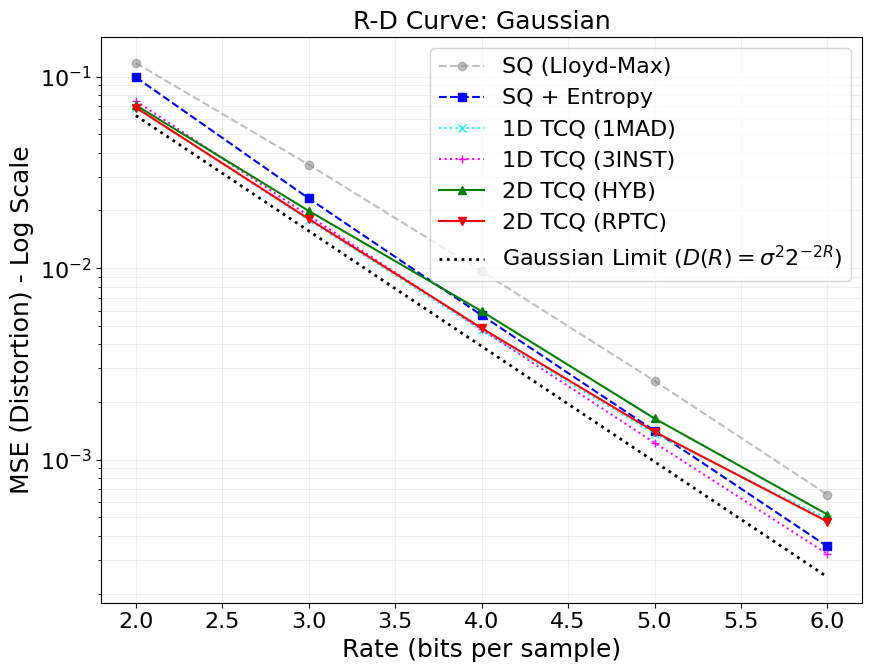


Running Experiment: Laplace
[Laplace] Stats: Mean=-0.0011, Std=1.0003
--------------------------------------------------------------------------------------------------------------
Rate  | Shannon    | SQ(Fix)    | SQ(Ent)    | 1MAD       | 3INST      | HYB        | RPTC      
--------------------------------------------------------------------------------------------------------------


Simulating (Laplace):  20%|██        | 1/5 [00:44<02:57, 44.34s/it]

2     | 0.05411    | 0.17631    | 0.08062    | 0.08427    | 0.07908    | 0.08532    | 0.07545   


Simulating (Laplace):  40%|████      | 2/5 [01:25<02:07, 42.50s/it]

3     | 0.01353    | 0.05464    | 0.01969    | 0.03087    | 0.02291    | 0.03860    | 0.02329   


...

4     | 0.00338    | 0.01535    | 0.00485    | 0.01634    | 0.00863    | 0.02006    | 0.00992   


Simulating (Laplace):  80%|████████  | 4/5 [02:45<00:40, 40.82s/it]

5     | 0.00085    | 0.00410    | 0.00121    | 0.01219    | 0.00487    | 0.00859    | 0.00526   


Simulating (Laplace): 100%|██████████| 5/5 [03:22<00:00, 40.60s/it]

6     | 0.00021    | 0.00105    | 0.00030    | 0.01100    | 0.00390    | 0.00438    | 0.00428   


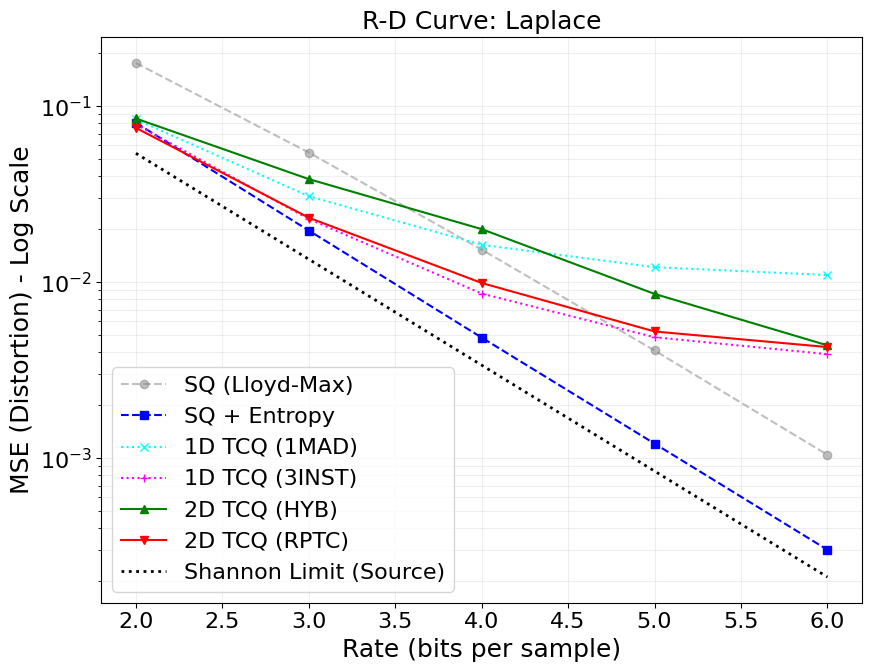


Running Experiment: Laplace + RHT
Applying Randomized Hadamard Transform to Laplace + RHT...
[Laplace + RHT] Stats: Mean=-0.0003, Std=0.9995
--------------------------------------------------------------------------------------------------------------
Rate  | Shannon    | SQ(Fix)    | SQ(Ent)    | 1MAD       | 3INST      | HYB        | RPTC      
--------------------------------------------------------------------------------------------------------------


Simulating (Laplace + RHT):  20%|██        | 1/5 [00:44<02:57, 44.35s/it]

2     | 0.06244    | 0.11782    | 0.09564    | 0.06909    | 0.07466    | 0.07108    | 0.06908   


Simulating (Laplace + RHT):  40%|████      | 2/5 [01:25<02:07, 42.48s/it]

3     | 0.01561    | 0.03478    | 0.02232    | 0.01793    | 0.01879    | 0.02002    | 0.01817   


...

4     | 0.00390    | 0.00966    | 0.00549    | 0.00477    | 0.00481    | 0.00602    | 0.00491   


Simulating (Laplace + RHT):  80%|████████  | 4/5 [02:45<00:40, 40.77s/it]

5     | 0.00098    | 0.00258    | 0.00136    | 0.00138    | 0.00123    | 0.00167    | 0.00142   


Simulating (Laplace + RHT): 100%|██████████| 5/5 [03:22<00:00, 40.52s/it]

6     | 0.00024    | 0.00067    | 0.00034    | 0.00049    | 0.00032    | 0.00053    | 0.00050   


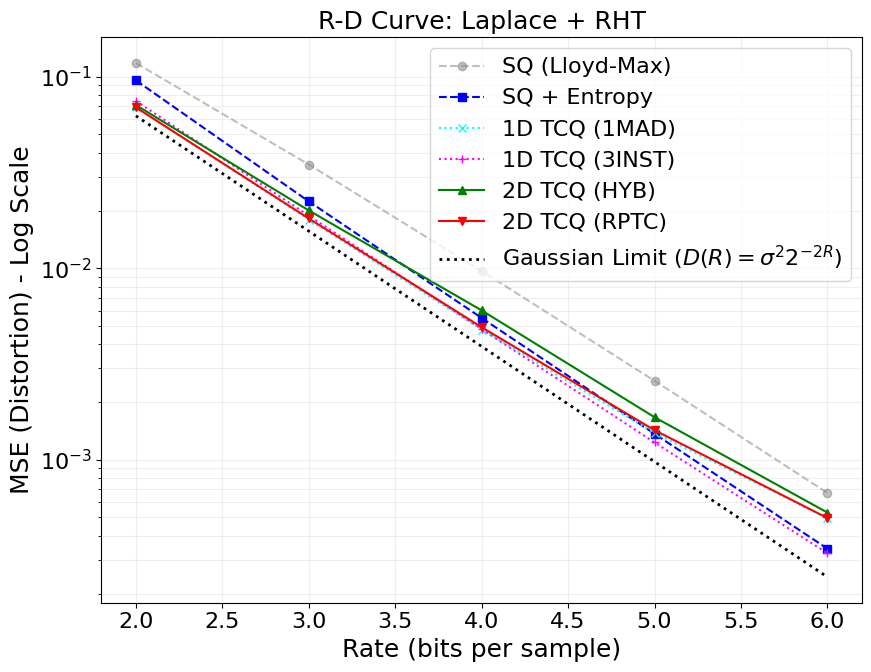


Running Experiment: Model Weights
[Model Weights] Stats: Mean=-0.0002, Std=1.0001
--------------------------------------------------------------------------------------------------------------
Rate  | Shannon    | SQ(Fix)    | SQ(Ent)    | 1MAD       | 3INST      | HYB        | RPTC      
--------------------------------------------------------------------------------------------------------------


Simulating (Model Weights):  20%|██        | 1/5 [00:44<02:56, 44.06s/it]

2     | 0.06040    | 0.16227    | 0.09310    | 0.08322    | 0.08202    | 0.08595    | 0.07537   


Simulating (Model Weights):  40%|████      | 2/5 [01:25<02:06, 42.33s/it]

3     | 0.01520    | 0.05679    | 0.02162    | 0.03157    | 0.02627    | 0.03775    | 0.02524   


...

4     | 0.00375    | 0.01852    | 0.00533    | 0.01795    | 0.01210    | 0.02078    | 0.01257   


Simulating (Model Weights):  80%|████████  | 4/5 [02:45<00:40, 40.72s/it]

5     | 0.00093    | 0.00534    | 0.00132    | 0.01425    | 0.00839    | 0.01135    | 0.00867   


Simulating (Model Weights): 100%|██████████| 5/5 [03:22<00:00, 40.58s/it]

6     | 0.00024    | 0.00188    | 0.00033    | 0.01323    | 0.00745    | 0.00758    | 0.00827   


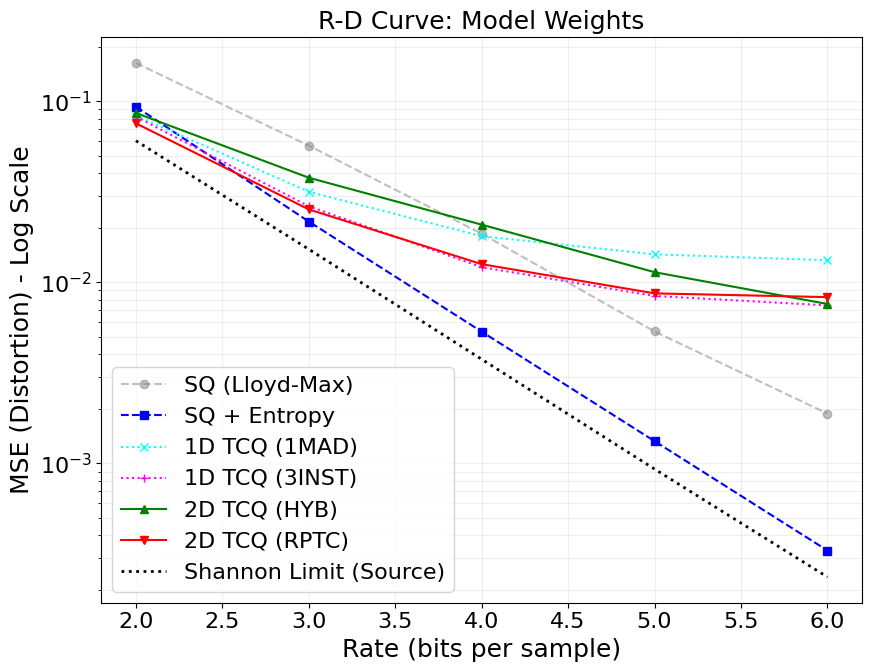


Running Experiment: Model Weights + RHT
Applying Randomized Hadamard Transform to Model Weights + RHT...
[Model Weights + RHT] Stats: Mean=-0.0000, Std=1.0001
--------------------------------------------------------------------------------------------------------------
Rate  | Shannon    | SQ(Fix)    | SQ(Ent)    | 1MAD       | 3INST      | HYB        | RPTC      
--------------------------------------------------------------------------------------------------------------


Simulating (Model Weights + RHT):  20%|██        | 1/5 [00:44<02:56, 44.02s/it]

2     | 0.06251    | 0.11811    | 0.09868    | 0.06928    | 0.07472    | 0.07125    | 0.06922   


Simulating (Model Weights + RHT):  40%|████      | 2/5 [01:24<02:06, 42.22s/it]

3     | 0.01563    | 0.03471    | 0.02309    | 0.01799    | 0.01881    | 0.02006    | 0.01820   


...

4     | 0.00391    | 0.00979    | 0.00566    | 0.00480    | 0.00481    | 0.00603    | 0.00494   


Simulating (Model Weights + RHT):  80%|████████  | 4/5 [02:44<00:40, 40.73s/it]

5     | 0.00098    | 0.00255    | 0.00141    | 0.00139    | 0.00123    | 0.00167    | 0.00143   


Simulating (Model Weights + RHT): 100%|██████████| 5/5 [03:22<00:00, 40.53s/it]

6     | 0.00024    | 0.00070    | 0.00035    | 0.00050    | 0.00033    | 0.00053    | 0.00050   


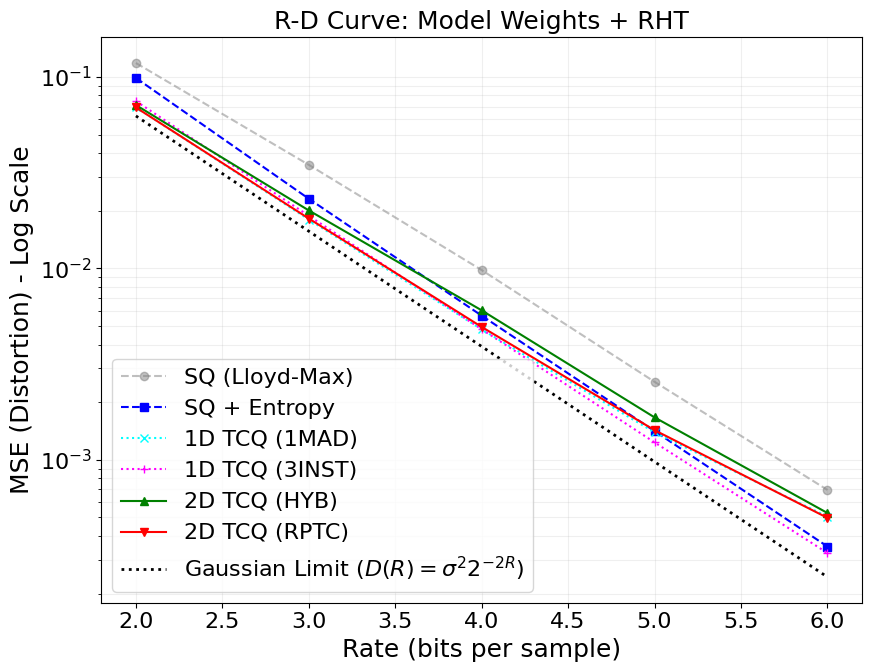

: 

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from tqdm import tqdm
import sys
import os
import logging
import warnings
from transformers import AutoModelForCausalLM
from scipy.linalg import hadamard # Hadamard 행렬 생성을 위해 추가

plt.rcParams['font.size'] = 16
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['legend.fontsize'] = 16
plt.rcParams['figure.titlesize'] = 20

# ==========================================
# 1. 초기 설정 (Imports & Setup)
# ==========================================
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', 'qtip'))
if project_root not in sys.path:
    sys.path.append(project_root)

# qtip 라이브러리가 없다면 에러가 날 수 있으므로 주의 (사용자 환경 전제)
try:
    from lib.codebook.bitshift import bitshift_codebook
except ImportError:
    print("Warning: 'qtip' library not found. Ensure project_root is correct.")

import torch._dynamo
import scipy.stats

# 에러 및 경고 억제
torch._dynamo.config.suppress_errors = True
torch._dynamo.reset()
logging.getLogger('torch._dynamo').setLevel(logging.ERROR)
logging.getLogger('torch._inductor').setLevel(logging.ERROR)
warnings.filterwarnings("ignore")

# 시드 고정
torch.manual_seed(42)
np.random.seed(42)

device = 'cuda:3' if torch.cuda.is_available() else 'cpu'
# RHT 블록 처리를 위해 256의 배수로 맞추는 것이 좋습니다.
N_SAMPLES = 1024 * 256 

# ==========================================
# 2. Model Weights 로딩
# ==========================================
print("Loading Model Weights...")

def get_named_linears(module):
    return {name: m for name, m in module.named_modules() if isinstance(m, nn.Linear)}

def get_blocks(model):
    if model.__class__.__name__ in ("LlamaForCausalLM", "Qwen2ForCausalLM"):
        layers = model.model.layers
    else:
        raise NotImplementedError(type(model))
    return layers

model_list = ['meta-llama/Meta-Llama-3-8B']
weight_norm = None

try:
    for model_name in model_list:
        model_name_safe = model_name.replace('/', '--')
        # 경로가 다르다면 수정 필요
        model_path = f"../Wparam_dataset/hf_model/{model_name_safe}"
        
        if not os.path.exists(model_path):
            print(f"Warning: Model path {model_path} not found. Skipping Weight experiment.")
            continue

        print(f'Loading from: {model_path}')
        model = AutoModelForCausalLM.from_pretrained(model_path, local_files_only=True)
        layers = get_blocks(model)
        
        weight = []
        # 시간 단축을 위해 일부 레이어만 추출하려면 range 조절
        for i in tqdm(range(len(layers)), desc="Extracting Weights"):
            named_linears = get_named_linears(layers[i])
            for n, m in named_linears.items():
                W = m.weight.data.detach().view(-1)
                weight.append(W)
        
        weight = torch.cat(weight, dim=0)
        
        # 정규화 (Normalization)
        mean = weight.mean()
        std = weight.std()
        weight_norm = (weight - mean) / std
        
        print(f"Weights Loaded: Mean={mean.item():.4f}, Std={std.item():.4f}")
        print(f"Normalized: Mean={weight_norm.mean().item():.4f}, Std={weight_norm.std().item():.4f}")
        
        del model
        torch.cuda.empty_cache()
        break 

except Exception as e:
    print(f"Error loading weights: {e}")
    weight_norm = None

# ==========================================
# 3. Helper Functions (RHT Added)
# ==========================================

def apply_rht(data, block_size=256):
    """
    Randomized Hadamard Transform 적용
    1. 데이터를 (N, BlockSize)로 Reshape
    2. Random Sign Flipping (Bernoulli 0.5)
    3. Walsh-Hadamard Transform 적용
    """
    n = len(data)
    # 패딩 (BlockSize 배수가 아닐 경우)
    pad = (block_size - (n % block_size)) % block_size
    if pad > 0:
        data = torch.cat([data, torch.zeros(pad, device=data.device, dtype=data.dtype)])
    
    # 2D Reshape (Batch, BlockSize)
    data_2d = data.view(-1, block_size).to(device)
    
    # Random Sign Generation (+1 or -1)
    # signs도 data와 같은 dtype을 가지도록 설정
    signs = torch.randint(0, 2, data_2d.shape, device=device).to(dtype=data.dtype) * 2 - 1
    data_signed = data_2d * signs
    
    # Hadamard Matrix 생성 (Scipy)
    # H 행렬을 data의 dtype에 맞춰서 변환 (type_as 사용)
    H_np = hadamard(block_size)
    H = torch.from_numpy(H_np).to(device).type_as(data_signed)
    
    # Orthogonal Transform: Scaling factor 1/sqrt(N)
    scale = 1.0 / np.sqrt(block_size)
    
    # (Batch, Block) @ (Block, Block) -> (Batch, Block)
    data_transformed = torch.matmul(data_signed, H) * scale
    
    # 다시 1D로 복구 및 패딩 제거
    return data_transformed.view(-1)[:n].cpu()

def calc_entropy(labels):
    unique, counts = np.unique(labels, return_counts=True)
    probs = counts / len(labels)
    return -np.sum(probs * np.log2(probs + 1e-10))

def uniform_quantization(x, step_size):
    if step_size < 1e-6: return x 
    return np.round(x / step_size) * step_size

def run_qtip_experiment(data_tensor, decode_mode, K=2, V=2, L=16, tlut_bits=None):
    if tlut_bits is None:
        tlut_bits = max(9, 2*K + 2)
        
    cb = bitshift_codebook(
        L=L, K=K, V=V, 
        tlut_bits=tlut_bits, 
        decode_mode=decode_mode
    ).to(device)
    
    # 입력 처리: (Batch, BlockSize=256)
    # 데이터가 256의 배수가 아니면 잘릴 수 있으니 패딩 처리 또는 resize 필요
    # 여기서는 간단히 view가 가능한 크기로 가정
    current_len = data_tensor.shape[0]
    trim_len = (current_len // 256) * 256
    data_in = data_tensor[:trim_len].view(-1, 256).to(device)
    
    with torch.no_grad():
        q_out = cb.quantize(data_in)
        recon = q_out[0]
        mse = torch.mean((data_in - recon) ** 2).item()
        
    return mse

def get_shannon_limit(data_np, R, source_name):
    """
    Shannon Lower Bound (SLB) 계산
    RHT가 적용된 소스는 'Gaussian'으로 간주하여 SLB 계산 (가우시안화 효과 반영)
    """
    sigma_sq = np.var(data_np)
    
    if "Gaussian" in source_name:
        return sigma_sq * (2 ** (-2 * R))
        
    elif "Laplace" in source_name and "RHT" not in source_name:
        # 순수 Laplace
        return (np.e / np.pi) * sigma_sq * (2 ** (-2 * R))
        
    else:
        # 일반 Model Weights 또는 RHT가 적용되지 않은 기타 분포
        # 데이터가 너무 많으면 샘플링
        sample_for_ent = data_np if len(data_np) < 20000 else np.random.choice(data_np, 20000)
        h_X = scipy.stats.differential_entropy(sample_for_ent, method='vasicek')
        coeff = (1.0 / (2 * np.pi * np.e)) * np.exp(2 * h_X)
        return coeff * (2 ** (-2 * R))

# ==========================================
# 4. Data Generators
# ==========================================
def get_gaussian_data():
    return torch.randn(N_SAMPLES)

def get_laplace_data():
    m = torch.distributions.laplace.Laplace(torch.tensor([0.0]), torch.tensor([1.0 / np.sqrt(2)]))
    return m.sample((N_SAMPLES,)).squeeze()

def get_weight_data():
    if weight_norm is None:
        raise ValueError("Weights not loaded properly.")
    # 전체 웨이트에서 랜덤 샘플링 (블록 처리를 위해 256 배수 유지)
    indices = torch.randint(0, len(weight_norm), (N_SAMPLES,))
    return weight_norm[indices]

# 실험 리스트 정의
experiments = [
    ("Gaussian", get_gaussian_data),
    ("Laplace", get_laplace_data),
]

# RHT 추가 실험 (Laplace)
experiments.append(("Laplace + RHT", get_laplace_data))

if weight_norm is not None:
    experiments.append(("Model Weights", get_weight_data))
    # RHT 추가 실험 (Weights)
    experiments.append(("Model Weights + RHT", get_weight_data))

# ==========================================
# 5. Main Experiment Loop
# ==========================================
R_targets = [2, 3, 4, 5, 6] 

for source_name, data_gen_func in experiments:
    print(f"\n{'='*40}")
    print(f"Running Experiment: {source_name}")
    print(f"{'='*40}")
    
    # 1. 데이터 생성
    data = data_gen_func()
    
    # 2. RHT 적용 여부 확인 및 변환
    is_rht = "RHT" in source_name
    if is_rht:
        print(f"Applying Randomized Hadamard Transform to {source_name}...")
        data = apply_rht(data, block_size=256)
    
    data_np = data.numpy()
    
    print(f"[{source_name}] Stats: Mean={data.mean():.4f}, Std={data.std():.4f}")

    results = {
        "R": [], "Shannon": [], "SQ_Fixed": [], "SQ_Entropy": [],
        "1D_TCQ_1MAD": [], "1D_TCQ_3INST": [], "2D_TCQ_HYB": [], "2D_TCQ_RPTC": []
    }

    print("-" * 110)
    print(f"{'Rate':<5} | {'Shannon':<10} | {'SQ(Fix)':<10} | {'SQ(Ent)':<10} | {'1MAD':<10} | {'3INST':<10} | {'HYB':<10} | {'RPTC':<10}")
    print("-" * 110)

    for R_target in tqdm(R_targets, desc=f"Simulating ({source_name})"):
        results["R"].append(R_target)
        
        # Shannon Limit: RHT 적용 시 Gaussian 분포로 가정하여 비교
        slb_source_name = "Gaussian" if is_rht else source_name
        D_shannon = get_shannon_limit(data_np, R_target, slb_source_name)
        results["Shannon"].append(D_shannon)

        # 2. SQ (Lloyd-Max)
        n_clusters = 2 ** R_target
        kmeans = KMeans(n_clusters=n_clusters, n_init=3, max_iter=50, random_state=42)
        # 샘플이 너무 많으면 KMeans가 느리므로 10만개로 제한하여 학습
        train_data = data_np if len(data_np) < 100000 else np.random.choice(data_np, 100000, replace=False)
        kmeans.fit(train_data.reshape(-1, 1))
        
        # 전체 데이터에 대한 예측
        # 메모리 절약을 위해 배치 처리 혹은 전체 처리 (여기선 간단히 전체)
        # 1D quantization mse ~ inertia / N
        # 정확한 계산을 위해 predict 사용
        q_indices = kmeans.predict(data_np.reshape(-1, 1))
        centers = kmeans.cluster_centers_.flatten()
        sq_recon = centers[q_indices]
        sq_mse = np.mean((data_np - sq_recon)**2)
        results["SQ_Fixed"].append(sq_mse)

        # 3. SQ + Entropy
        low, high = 0.001, 10.0
        best_step = 1.0
        # 이진 탐색으로 타겟 Rate(Entropy)에 맞는 step size 찾기
        sample_for_ent = data_np if len(data_np) < 50000 else data_np[:50000]
        
        for _ in range(15): 
            mid = (low + high) / 2
            q_vals = np.round(sample_for_ent / mid)
            h = calc_entropy(q_vals)
            if h > R_target: low = mid
            else: high = mid; best_step = mid
        
        ecsq_recon = uniform_quantization(data_np, best_step)
        ecsq_mse = np.mean((data_np - ecsq_recon)**2)
        results["SQ_Entropy"].append(ecsq_mse)

        # 4. TCQ Experiments
        # 1MAD
        tcq_1mad = run_qtip_experiment(data, decode_mode='1mad', K=R_target, V=1, tlut_bits=0)
        results["1D_TCQ_1MAD"].append(tcq_1mad)
        
        # 3INST
        tcq_3inst = run_qtip_experiment(data, decode_mode='3inst', K=R_target, V=1, tlut_bits=0)
        results["1D_TCQ_3INST"].append(tcq_3inst)

        # HYB (2D, Quantized LUT)
        tcq_hyb = run_qtip_experiment(data, decode_mode='quantlut_sym', K=R_target, V=2, tlut_bits=None)
        results["2D_TCQ_HYB"].append(tcq_hyb)
        
        # RPTC (2D, Full LUT)
        tcq_rptc = run_qtip_experiment(data, decode_mode='lut', K=R_target, V=2, tlut_bits=16)
        results["2D_TCQ_RPTC"].append(tcq_rptc)

        print(f"{R_target:<5} | {D_shannon:<10.5f} | {sq_mse:<10.5f} | {ecsq_mse:<10.5f} | {tcq_1mad:<10.5f} | {tcq_3inst:<10.5f} | {tcq_hyb:<10.5f} | {tcq_rptc:<10.5f}")

    # ==========================================
    # Plotting
    # ==========================================
    plt.figure(figsize=(9, 7))
    plt.semilogy(results["R"], results["SQ_Fixed"], 'o--', label='SQ (Lloyd-Max)', color='gray', alpha=0.5)
    plt.semilogy(results["R"], results["SQ_Entropy"], 's--', label='SQ + Entropy', color='blue')
    plt.semilogy(results["R"], results["1D_TCQ_1MAD"], 'x:', label='1D TCQ (1MAD)', color='cyan')
    plt.semilogy(results["R"], results["1D_TCQ_3INST"], '+:', label='1D TCQ (3INST)', color='magenta')
    plt.semilogy(results["R"], results["2D_TCQ_HYB"], '^-', label='2D TCQ (HYB)', color='green')
    plt.semilogy(results["R"], results["2D_TCQ_RPTC"], 'v-', label='2D TCQ (RPTC)', color='red')
    
    # Shannon Limit 라벨링 (RHT인 경우 Gaussian Limit임을 명시)
    limit_label = 'Gaussian Limit ($D(R) = \sigma^2 2^{-2R}$)' if is_rht or source_name == 'Gaussian' else 'Shannon Limit (Source)'
    plt.semilogy(results["R"], results["Shannon"], 'k:', label=limit_label, linewidth=2)

    plt.title(f"R-D Curve: {source_name}")
    plt.xlabel("Rate (bits per sample)")
    plt.ylabel("MSE (Distortion) - Log Scale")
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.legend()
    plt.tight_layout()
    plt.show()